# Task 3 — Clustering

Compare k-means, hierarchical clustering and Leiden on a donor-balanced PBMC sample.
Each method or linkage is selected by score, optionally restricted by resampling stability.
Marker profiles describe relatively higher and lower expression.

In [ ]:
from pathlib import Path
import os

# Set thread limits before importing numerical libraries.
for variable in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                 "NUMBA_NUM_THREADS"]:
    os.environ[variable] = "2"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import flowio
import scanpy as sc

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (davies_bouldin_score, calinski_harabasz_score,
                             silhouette_score)
from scipy.cluster.hierarchy import linkage, cut_tree
from numba import set_num_threads
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "NK_cell_dataset").exists():
    ROOT = ROOT.parent

METRIC = "davies_bouldin"  # alternatives: "silhouette", "calinski_harabasz"

USE_STABILITY_FILTER = True
N_RESAMPLES = 10
SUBSAMPLE_FRACTION = 0.80
LINKAGES = ["single", "average", "complete", "ward"]

SEED = 42
CELLS_PER_DONOR = 500
COFACTOR = 5
K_VALUES = [2, 3, 4, 6, 8, 10, 12, 14]
NEIGHBORS = [10, 30, 60]
RESOLUTIONS = [0.3, 0.7, 1.2]

score_function, lower_is_better = {
    "davies_bouldin": (davies_bouldin_score, True),
    "silhouette": (silhouette_score, False),
    "calinski_harabasz": (calinski_harabasz_score, False),
}[METRIC]

set_num_threads(2)
sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", 15)
print(f"Selection: {METRIC}; {'lower' if lower_is_better else 'higher'} is better")

Selection: davies_bouldin; lower is better


## 1. Read the data

Read the alive PBMC files corresponding to the donor list and sample up to
`CELLS_PER_DONOR` cells from each donor. Keep the 37 markers listed in the CSV,
including finite negative background values. Donor and FCS event indices are retained.
`ignore_offset_error=True` handles the known one-byte offset error in these exports.

In [12]:
def find_data_folder(root):
    data_root = root / "NK_cell_dataset"
    for candidate in (data_root, data_root / "NK_cell_dataset"):
        if all((candidate / name).is_file() for name in
               ("NK_markers.csv", "NK_fcs_samples_with_labels.csv")):
            return candidate
    raise FileNotFoundError(f"Marker and donor CSVs not found under {data_root}")


folder = find_data_folder(ROOT)
markers = pd.read_csv(folder / "NK_markers.csv").columns.tolist()
donors = pd.read_csv(folder / "NK_fcs_samples_with_labels.csv")
rng = np.random.default_rng(SEED)
samples, cell_metadata = [], []

for filename in donors["fcs_filename"]:
    alive_name = filename.replace("_NK.fcs", "_alive.fcs")
    path = next(folder.rglob(alive_name))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*incorrect data offset.*")
        fcs = flowio.FlowData(str(path), ignore_offset_error=True)

    channels = [fcs.channels[i]["pns"] for i in range(1, fcs.channel_count + 1)]
    events = np.asarray(fcs.events).reshape(fcs.event_count, fcs.channel_count)
    values = events[:, [channels.index(marker) for marker in markers]]
    valid = np.flatnonzero(np.isfinite(values).all(axis=1))
    selected = np.sort(rng.choice(valid, min(CELLS_PER_DONOR, len(valid)), replace=False))
    samples.append(values[selected])
    cell_metadata.append(pd.DataFrame({"donor": filename, "event": selected}))

raw = np.vstack(samples)
cell_info = pd.concat(cell_metadata, ignore_index=True)
print(f"{len(donors)} donors; {raw.shape[0]} cells; {raw.shape[1]} markers")

20 donors; 10000 cells; 37 markers


## 2. Fixed preprocessing and scoring

Apply arcsinh(x / 5), then standardise each marker to zero mean and unit variance.
All methods are fitted and scored on this matrix `X`. Marker profiles use arcsinh values.
Scaling gives noisy markers the same variance as other markers; sampling can miss rare populations.

Davies–Bouldin is minimised; silhouette and Calinski–Harabasz are maximised.
Changing `METRIC` requires rerunning from the settings cell.

In [13]:
arcsinh_values = np.arcsinh(raw / COFACTOR)
X = StandardScaler().fit_transform(arcsinh_values)

def evaluate(labels):
    if not 1 < len(np.unique(labels)) < len(labels):
        return np.nan
    return score_function(X, labels)

## 3. Grid search

- K-means: test `K_VALUES` with 10 initialisations per fit.
- Hierarchical: single, average, complete and Ward linkage with Euclidean distances;
  cut each tree at `K_VALUES`. Ward minimises the increase in within-cluster sum of squares.
- Leiden: test neighbour counts and resolutions on a weighted, undirected graph
  built directly from `X`. Use `leidenalg` with its default RBConfiguration objective
  and `n_iterations=-1`.

More neighbours make the graph less local; higher resolution usually produces more clusters.
Configurations are identified by method and parameters. Numeric IDs are used in tables and plots.

In [14]:
def configuration_key(method, parameters):
    return method, tuple(sorted(parameters.items()))


def grid_settings():
    return {
        "k": frozenset(K_VALUES),
        "linkages": frozenset(LINKAGES),
        "neighbors": frozenset(NEIGHBORS),
        "resolutions": frozenset(RESOLUTIONS),
    }


def fit_grid(values, seed):
    for k in K_VALUES:
        labels = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(values)
        yield "k-means", {"k": k}, labels

    for link in LINKAGES:
        tree = linkage(values, method=link, metric="euclidean")
        for k in K_VALUES:
            yield f"Hierarchical ({link})", {"k": k}, cut_tree(tree, n_clusters=k).ravel()

    adata = sc.AnnData(values)
    for neighbors in NEIGHBORS:
        sc.pp.neighbors(adata, n_neighbors=neighbors, use_rep="X", random_state=seed)
        for resolution in RESOLUTIONS:
            sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
                         directed=False, n_iterations=-1, random_state=seed)
            yield "Leiden", {"neighbors": neighbors, "resolution": resolution}, (
                adata.obs["leiden"].astype(int).to_numpy())

fitted_grid_settings = grid_settings()
records, partitions, configuration_ids = [], {}, {}
for run_id, (method, parameters, labels) in enumerate(fit_grid(X, SEED)):
    key = configuration_key(method, parameters)
    if key in configuration_ids:
        raise ValueError(f"Duplicate grid configuration: {key}")
    configuration_ids[key] = run_id
    sizes = np.unique(labels, return_counts=True)[1]
    partitions[run_id] = labels.copy()
    records.append(dict(id=run_id, method=method, score=evaluate(labels),
                        clusters=len(sizes), smallest=int(sizes.min()),
                        largest_pct=100 * sizes.max() / len(labels),
                        sizes=sorted(sizes.tolist(), reverse=True), **parameters))
grid = pd.DataFrame(records)
display(grid.round(3))

C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_18888\3014677177.py:28: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_18888\3014677177.py:28: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_18888\3014677177.py:28: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_18888\3014677177.py:28: UserWarning: Th

,id,method,score,clusters,smallest,largest_pct,sizes,k,neighbors,resolution
0,0,k-means,2.446,2,1859,81.41,"[8141, 1859]",2.0,NaN,NaN
1,1,k-means,2.435,3,1656,42.26,"[4226, 4118, 1656]",3.0,NaN,NaN
2,2,k-means,2.374,4,1519,38.66,"[3866, 2495, 2120, 1519]",4.0,NaN,NaN
3,3,k-means,2.467,6,246,24.37,"[2437, 2117, 2106, 1916, 1178, 246]",6.0,NaN,NaN
4,4,k-means,2.596,8,233,19.64,"[1964, 1856, 1487, 1379, 1108, 1007, 966, 233]",8.0,NaN,NaN
5,5,k-means,2.665,10,181,18.43,"[1843, 1492, 1452, 1362, 1321, 936, 707, 477, ...",10.0,NaN,NaN
6,6,k-means,2.589,12,224,15.48,"[1548, 1365, 1314, 1291, 1046, 881, 595, 593, ...",12.0,NaN,NaN
7,7,k-means,2.594,14,169,13.44,"[1344, 1275, 1240, 1199, 974, 954, 601, 570, 5...",14.0,NaN,NaN
8,8,Hierarchical (single),0.182,2,1,99.99,"[9999, 1]",2.0,NaN,NaN
9,9,Hierarchical (single),0.274,3,1,99.98,"[9998, 1, 1]",3.0,NaN,NaN


## 4. Resampling stability

For each of 10 repeats, retain 80% of the original sample within each donor without
replacement. Refit scaling and clustering, using a new random seed. Every configuration
uses the same retained cells in a repeat. Reordering the grid is allowed; changing its
parameter values requires rerunning section 3.

For each original cluster, take its largest Jaccard overlap with a resampled cluster,
comparing only retained cells. An absent cluster receives NaN. Cluster labels are local
to each configuration and repeat.

Stability is the unweighted mean of the per-cluster median Jaccards. Strong clusters
can compensate for weak ones. A cluster absent in every repeat makes the configuration
unassessable; the tables also show the number of evaluated repeats. Singletons can score
1 when retained. No minimum cluster-size or repeat-count filter is applied.

This assesses cell removal, refitted scaling and algorithmic randomness together, within
the initial sample. It does not test new donors or a fresh sample of cells.
Set `USE_STABILITY_FILTER=False` to skip resampling.

In [15]:
def cluster_jaccard(original, reclustered, cluster_ids):
    original_ids, original_index = np.unique(original, return_inverse=True)
    _, new_index = np.unique(reclustered, return_inverse=True)
    counts = np.zeros((len(original_ids), new_index.max() + 1), dtype=int)
    np.add.at(counts, (original_index, new_index), 1)
    unions = counts.sum(axis=1)[:, None] + counts.sum(axis=0)[None, :] - counts
    best = dict(zip(original_ids, (counts / unions).max(axis=1)))
    # Clusters absent from the retained cells cannot be assessed.
    return {int(cluster): best.get(cluster, np.nan) for cluster in cluster_ids}

def estimate_stability():
    if grid_settings() != fitted_grid_settings:
        raise ValueError("Grid parameters changed. Rerun section 3 before stability.")
    rng = np.random.default_rng(SEED + 1)
    donor_groups = [rows.to_numpy() for rows in cell_info.groupby("donor", sort=False).groups.values()]
    rows = []
    for repeat in range(N_RESAMPLES):
        retained = np.sort(np.concatenate([
            rng.choice(group, max(1, int(np.floor(SUBSAMPLE_FRACTION * len(group)))),
                       replace=False) for group in donor_groups
        ]))
        subset_x = StandardScaler().fit_transform(arcsinh_values[retained])

        seen = set()
        for method, parameters, labels in fit_grid(subset_x, SEED + repeat + 1):
            key = configuration_key(method, parameters)
            if key not in configuration_ids or key in seen:
                raise ValueError(f"Unexpected or duplicate configuration: {key}. Rerun section 3.")
            seen.add(key)
            run_id = configuration_ids[key]
            original = partitions[run_id]
            overlap = cluster_jaccard(original[retained], labels, np.unique(original))
            for cluster, value in overlap.items():
                rows.append(dict(id=run_id, repeat=repeat, cluster=cluster,
                                 jaccard=value,
                                 retained_cells=int((original[retained] == cluster).sum())))
        if seen != set(configuration_ids):
            raise ValueError("Incomplete resampling grid. Rerun section 3 before stability.")
        print(f"Stability: {repeat + 1}/{N_RESAMPLES} repeats finished", flush=True)

    trials = pd.DataFrame(rows)
    summary = trials.groupby(["id", "cluster"]).agg(
        median_jaccard=("jaccard", "median"),
        q25=("jaccard", lambda values: values.quantile(0.25)),
        q75=("jaccard", lambda values: values.quantile(0.75)),
        evaluated_repeats=("jaccard", "count"),
        min_retained=("retained_cells", "min"),
    ).reset_index()
    summary["original_cells"] = [
        int((partitions[int(row.id)] == row.cluster).sum()) for row in summary.itertuples()
    ]
    # Keep the score undefined if a cluster was absent in every repeat.
    stability = summary.groupby("id").median_jaccard.agg(
        lambda values: values.mean() if values.notna().all() else np.nan)
    return trials, summary, stability

stability_trials = pd.DataFrame()
cluster_stability = pd.DataFrame()
if USE_STABILITY_FILTER:
    stability_trials, cluster_stability, stability = estimate_stability()
    grid["stability"] = grid.id.map(stability)
else:
    grid["stability"] = np.nan
grid.attrs["stability_evaluated"] = USE_STABILITY_FILTER

## 5. Select configurations

Set `STABILITY_THRESHOLD` in the cell below. Select the best score among eligible
configurations separately for each method/linkage. If none pass, leave that method empty.

After changing the threshold, rerun this section and all following cells; resampling
does not need to be repeated. Each selection prints the applied cutoff.

Inspect individual cluster medians alongside the mean. Blank heatmap entries are unassessable
or correspond to cluster IDs that do not exist in that configuration.

In [16]:
STABILITY_THRESHOLD = 0.6


def select_winners(results, use_stability, threshold):
    evaluated = results.copy()
    evaluated["eligible"] = np.isfinite(evaluated.score)
    if use_stability:
        if not evaluated.attrs.get("stability_evaluated", False):
            raise ValueError("Run the stability cell first before enabling its filter.")
        evaluated["eligible"] &= evaluated.stability.ge(threshold)
    ranked = evaluated[evaluated.eligible].sort_values(
        "score", ascending=lower_is_better, kind="stable")
    selected = ranked.drop_duplicates("method").set_index("method")
    return evaluated, selected

grid, selected = select_winners(grid, USE_STABILITY_FILTER, STABILITY_THRESHOLD)
selection_description = (
    f"Selection: {METRIC}; stability >= {STABILITY_THRESHOLD:g}"
    if USE_STABILITY_FILTER else f"Selection: {METRIC}; stability filter off"
)
print(selection_description)
method_names = ["k-means"] + [f"Hierarchical ({link})" for link in LINKAGES] + ["Leiden"]
winners = selected.reindex(method_names)
winner_ids = {name: int(winners.loc[name, "id"]) for name in method_names
              if pd.notna(winners.loc[name, "id"])}
display(grid.round(3))
display(winners[["k", "neighbors", "resolution", "score", "stability",
                 "clusters", "largest_pct", "sizes"]].round(3))
for name in method_names:
    if name not in winner_ids:
        print(f"{name}: no eligible configuration; no fallback winner.")

if USE_STABILITY_FILTER:
    fig, ax = plt.subplots(figsize=(12, 4))
    for name, rows in grid.groupby("method", sort=False):
        ax.scatter(rows.id, rows.stability, label=name)
    ax.axhline(STABILITY_THRESHOLD, color="black", linestyle="--", label="Threshold")
    ax.set(xlabel="Grid configuration ID", ylabel="Mean of cluster median Jaccards",
           title="Stability eligibility", ylim=(-0.03, 1.03))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

if USE_STABILITY_FILTER and winner_ids:
    selected_clusters = cluster_stability[cluster_stability.id.isin(winner_ids.values())].copy()
    selected_clusters["method"] = selected_clusters.id.map({v: k for k, v in winner_ids.items()})
    display(selected_clusters[["method", "cluster", "original_cells", "median_jaccard",
                               "q25", "q75", "evaluated_repeats", "min_retained"]].round(3))

if USE_STABILITY_FILTER:
    fig, axes = plt.subplots(3, 2, figsize=(20, 14))
    for ax, name in zip(axes.ravel(), method_names):
        runs = grid[grid.method == name]
        values = cluster_stability[cluster_stability.id.isin(runs.id)]
        matrix = values.pivot(index="id", columns="cluster", values="median_jaccard")
        row_labels = {}
        for row in runs.itertuples():
            setting = (f"k={int(row.k)}" if pd.notna(row.k)
                       else f"n={int(row.neighbors)}, r={row.resolution:g}")
            row_labels[row.id] = f"ID {row.id}: {setting}"
        matrix = matrix.rename(index=row_labels)
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
                    ax=ax, annot_kws={"fontsize": 7},
                    cbar_kws={"label": "Median Jaccard"})
        ax.set(title=name, xlabel="Cluster ID within this configuration", ylabel="Configuration")
    fig.suptitle("Individual cluster stability across the entire grid")
    fig.tight_layout()
    plt.show()

Selection: davies_bouldin; stability filter off


,id,method,score,clusters,smallest,largest_pct,sizes,k,neighbors,resolution,stability,eligible
0,0,k-means,2.446,2,1859,81.41,"[8141, 1859]",2.0,NaN,NaN,NaN,True
1,1,k-means,2.435,3,1656,42.26,"[4226, 4118, 1656]",3.0,NaN,NaN,NaN,True
2,2,k-means,2.374,4,1519,38.66,"[3866, 2495, 2120, 1519]",4.0,NaN,NaN,NaN,True
3,3,k-means,2.467,6,246,24.37,"[2437, 2117, 2106, 1916, 1178, 246]",6.0,NaN,NaN,NaN,True
4,4,k-means,2.596,8,233,19.64,"[1964, 1856, 1487, 1379, 1108, 1007, 966, 233]",8.0,NaN,NaN,NaN,True
5,5,k-means,2.665,10,181,18.43,"[1843, 1492, 1452, 1362, 1321, 936, 707, 477, ...",10.0,NaN,NaN,NaN,True
6,6,k-means,2.589,12,224,15.48,"[1548, 1365, 1314, 1291, 1046, 881, 595, 593, ...",12.0,NaN,NaN,NaN,True
7,7,k-means,2.594,14,169,13.44,"[1344, 1275, 1240, 1199, 974, 954, 601, 570, 5...",14.0,NaN,NaN,NaN,True
8,8,Hierarchical (single),0.182,2,1,99.99,"[9999, 1]",2.0,NaN,NaN,NaN,True
9,9,Hierarchical (single),0.274,3,1,99.98,"[9998, 1, 1]",3.0,NaN,NaN,NaN,True


,k,neighbors,resolution,score,stability,clusters,largest_pct,sizes
method,,,,,,,,
k-means,4.0,NaN,NaN,2.374,NaN,4,38.66,"[3866, 2495, 2120, 1519]"
Hierarchical (single),2.0,NaN,NaN,0.182,NaN,2,99.99,"[9999, 1]"
Hierarchical (average),2.0,NaN,NaN,0.182,NaN,2,99.99,"[9999, 1]"
Hierarchical (complete),2.0,NaN,NaN,0.182,NaN,2,99.99,"[9999, 1]"
Hierarchical (ward),4.0,NaN,NaN,2.581,NaN,4,55.00,"[5500, 2737, 1592, 171]"
Leiden,NaN,60.0,0.3,2.353,NaN,4,39.60,"[3960, 3023, 1658, 1359]"


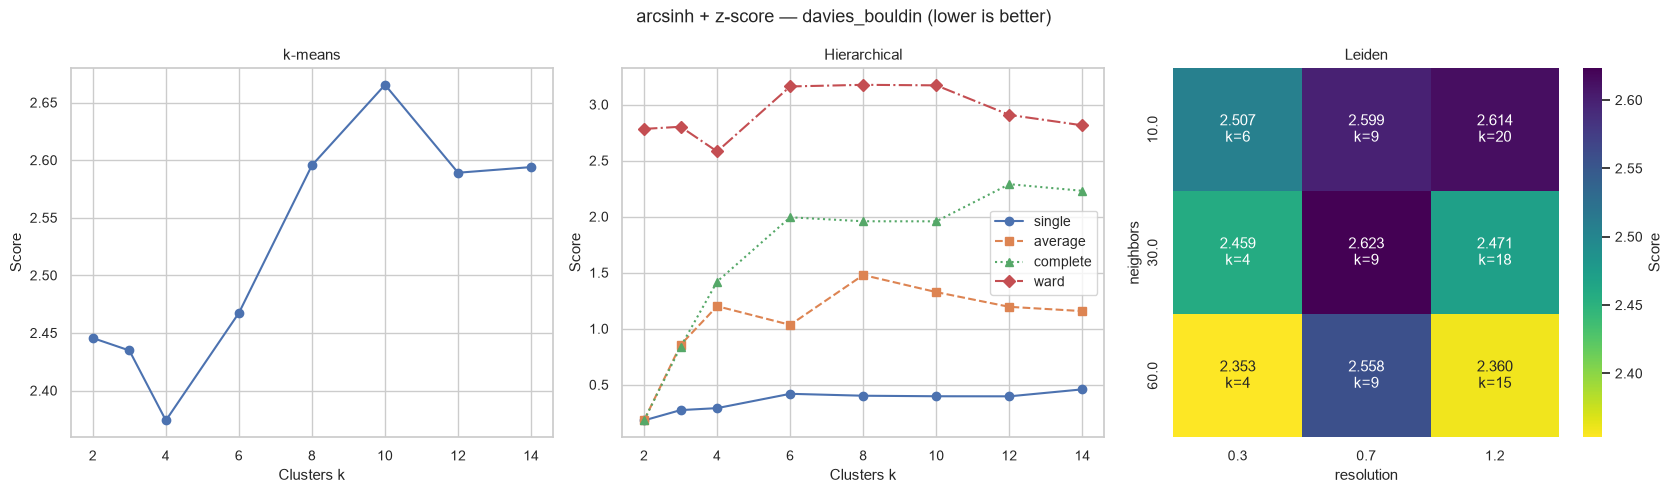

In [17]:
direction = "lower is better" if lower_is_better else "higher is better"
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
rows = grid[grid.method == "k-means"]
axes[0].plot(rows.k, rows.score, marker="o")
axes[0].set(title="k-means", xlabel="Clusters k", ylabel="Score")

for link, style, marker in [("single", "-", "o"), ("average", "--", "s"), ("complete", ":", "^"), ("ward", "-.", "D")]:
    rows = grid[grid.method == f"Hierarchical ({link})"]
    axes[1].plot(rows.k, rows.score, linestyle=style, marker=marker, label=link)
axes[1].set(title="Hierarchical", xlabel="Clusters k", ylabel="Score")
axes[1].legend()

rows = grid[grid.method == "Leiden"]
scores = rows.pivot(index="neighbors", columns="resolution", values="score")
counts = rows.pivot(index="neighbors", columns="resolution", values="clusters")
labels = scores.copy().astype(str)
for neighbor in scores.index:
    for resolution in scores.columns:
        labels.loc[neighbor, resolution] = (
            f"{scores.loc[neighbor, resolution]:.3f}\nk={counts.loc[neighbor, resolution]}")
sns.heatmap(scores, annot=labels, fmt="", ax=axes[2],
            cmap="viridis_r" if lower_is_better else "viridis", cbar_kws={"label": "Score"})
axes[2].set_title("Leiden")
fig.suptitle(f"arcsinh + z-score — {METRIC} ({direction})")
fig.tight_layout()
plt.show()

## 6. Descriptive marker profiles

For each marker, compute (cluster median − sample median) / sample IQR on arcsinh values.
Show up to `TOP_MARKERS` relatively higher and lower markers above `MIN_MARKER_EFFECT`
in magnitude. A zero IQR leaves the marker unscored.

These are relative expression descriptions. Cluster medians do not establish co-expression
in individual cells. All heatmaps share the same marker order and colour scale.

,method,cluster,cells,higher_markers (IQR units),lower_markers (IQR units)
0,k-means,0,2495,"CD34 (+1.35), CD33 (+0.78), ILT2-CD85j (+0.75)",—
1,k-means,1,1519,"NKp46 (+4.02), CD10 (+3.05), CD94 (+2.53)",—
2,k-means,2,2120,"CD19 (+1.42), HLA-DR (+0.54), 2DL4 (+0.53)",CD3 (-0.83)
3,k-means,3,3866,CD127 (+0.68),—
4,Hierarchical (single),0,9999,—,—
5,Hierarchical (single),1,1,"2DL1-S1 (+47.32), 2DL2-L3-S2 (+40.86), CD10 (+...",—
6,Hierarchical (average),0,9999,—,—
7,Hierarchical (average),1,1,"2DL1-S1 (+47.32), 2DL2-L3-S2 (+40.86), CD10 (+...",—
8,Hierarchical (complete),0,9999,—,—
9,Hierarchical (complete),1,1,"2DL1-S1 (+47.32), 2DL2-L3-S2 (+40.86), CD10 (+...",—


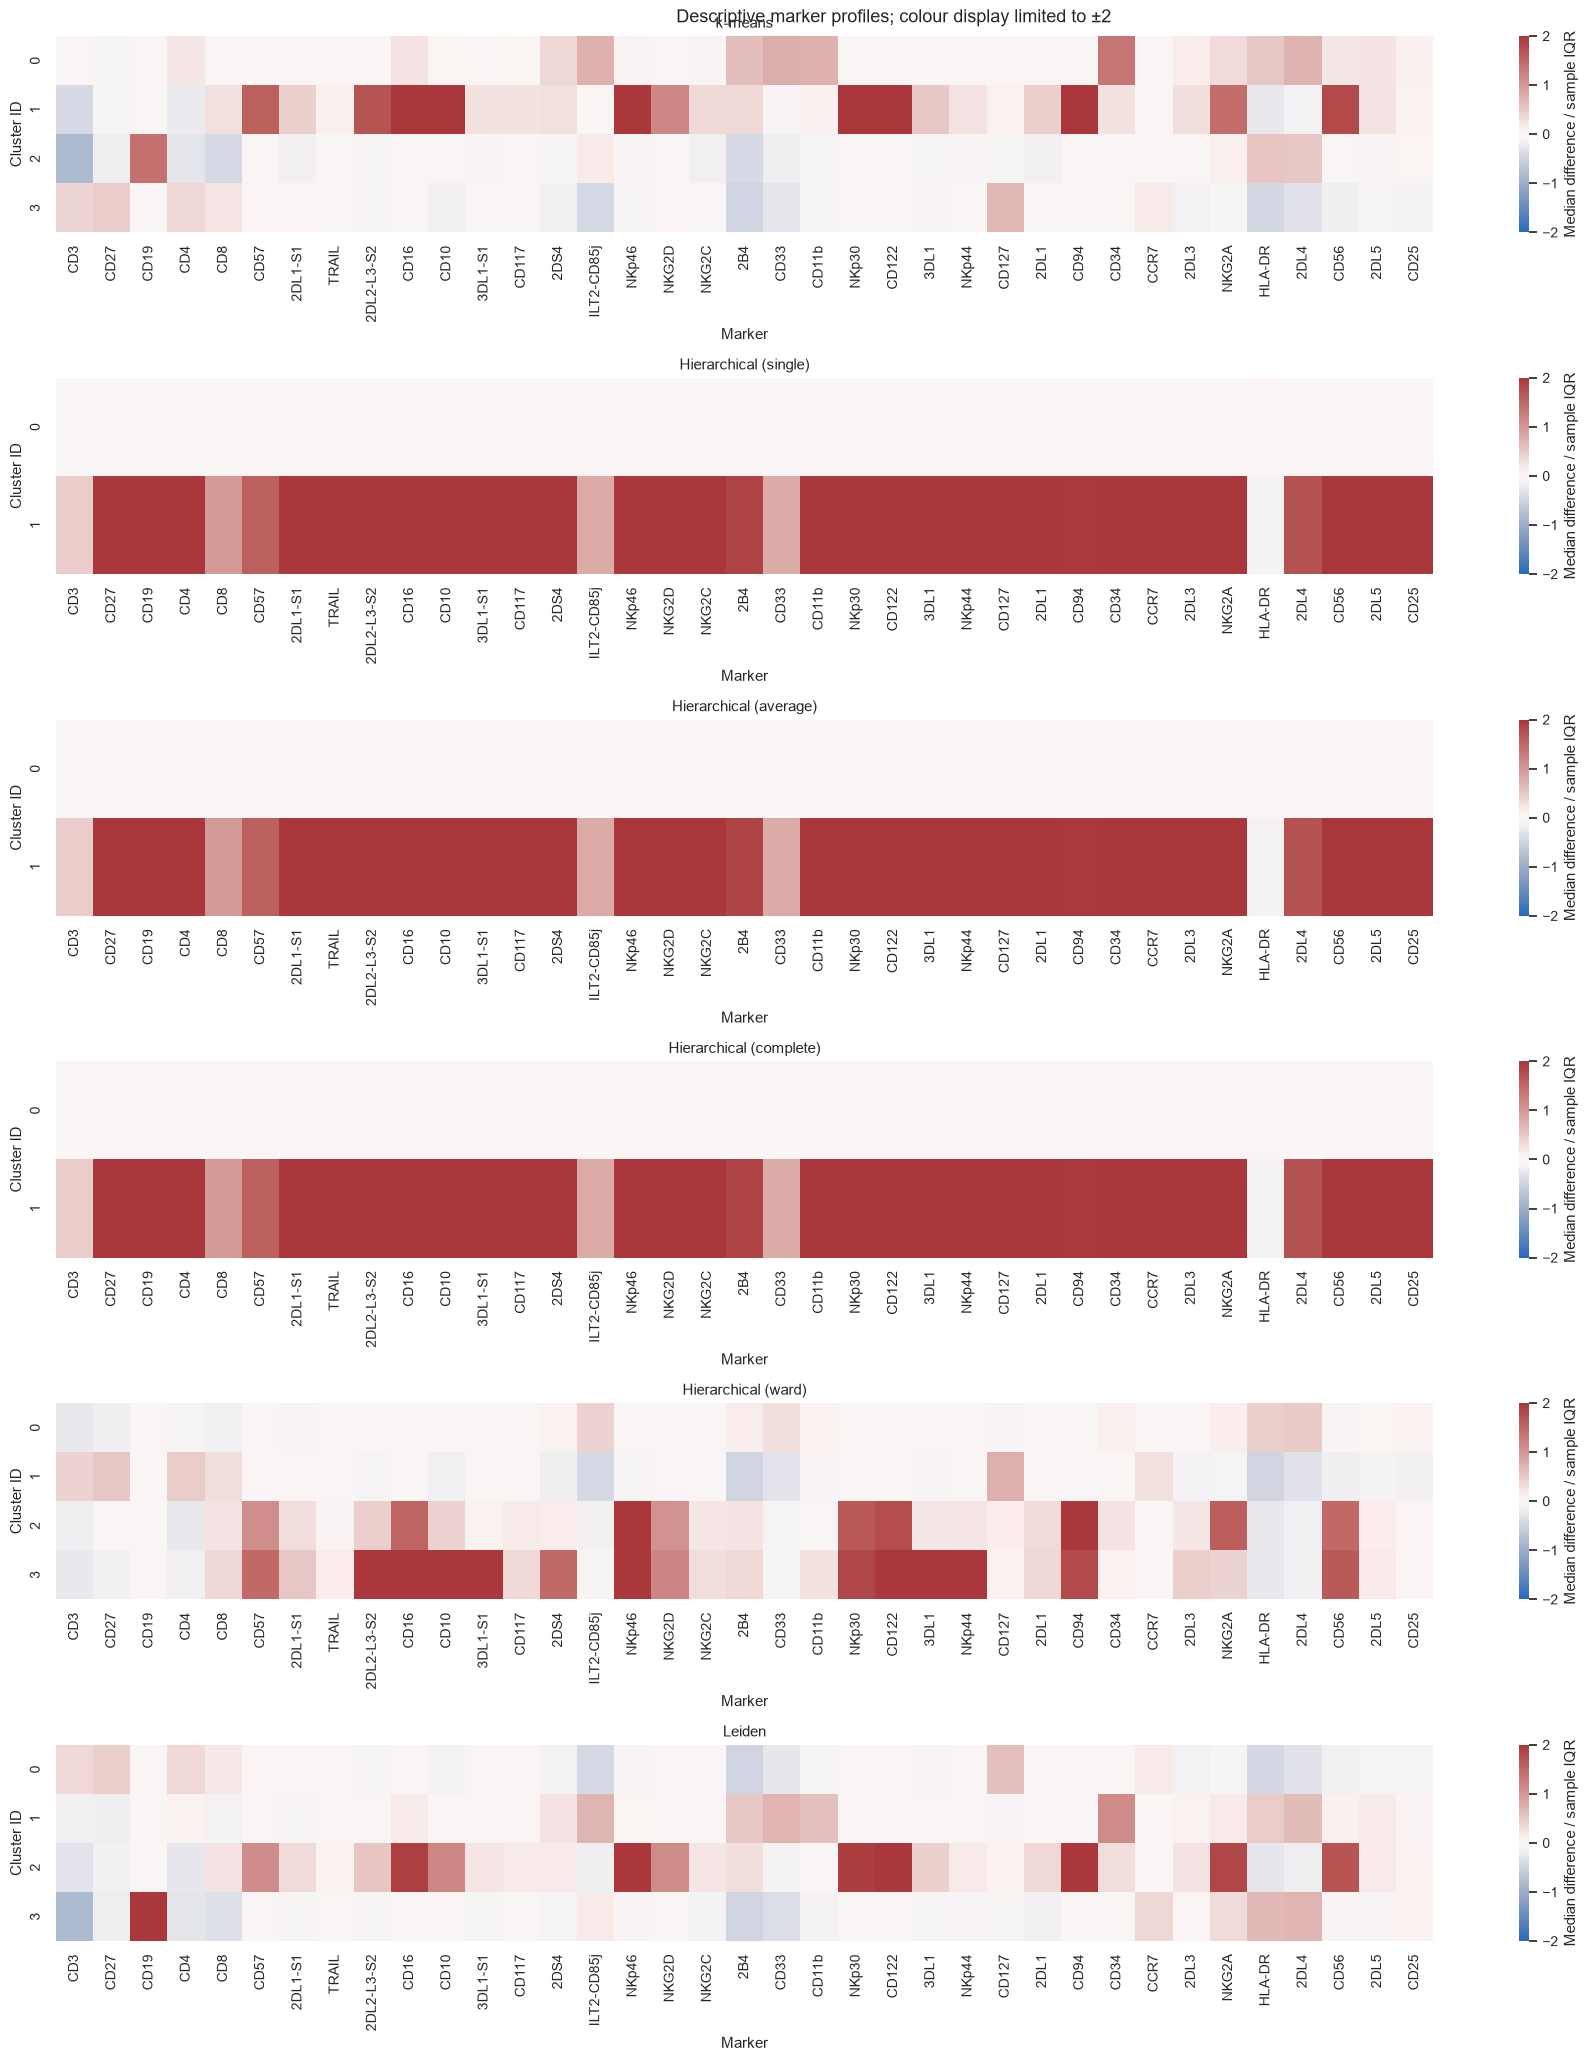

In [18]:
TOP_MARKERS = 3
MIN_MARKER_EFFECT = 0.5  # Sample IQR units.

expression = pd.DataFrame(arcsinh_values, columns=markers)
sample_median = expression.median()
sample_iqr = (expression.quantile(0.75) - expression.quantile(0.25)).replace(0, np.nan)
profiles, relative_profiles, marker_annotations = {}, {}, {}
profile_rows = []

for name, run_id in winner_ids.items():
    labels = partitions[run_id]
    profiles[name] = expression.groupby(labels).median()
    relative_profiles[name] = (profiles[name] - sample_median) / sample_iqr
    marker_annotations[name] = {}
    for cluster, values in relative_profiles[name].iterrows():
        higher = values[values >= MIN_MARKER_EFFECT].nlargest(TOP_MARKERS)
        lower = values[values <= -MIN_MARKER_EFFECT].nsmallest(TOP_MARKERS)
        descriptions = []
        if not higher.empty:
            descriptions.append("higher: " + ", ".join(higher.index))
        if not lower.empty:
            descriptions.append("lower: " + ", ".join(lower.index))
        marker_annotations[name][cluster] = (
            "; ".join(descriptions) if descriptions else "No marked median difference")
        profile_rows.append({
            "method": name, "cluster": cluster, "cells": int((labels == cluster).sum()),
            "higher_markers (IQR units)": ", ".join(f"{m} ({v:+.2f})" for m, v in higher.items()) or "—",
            "lower_markers (IQR units)": ", ".join(f"{m} ({v:+.2f})" for m, v in lower.items()) or "—",
        })

marker_summary = pd.DataFrame(profile_rows)
display(marker_summary)
if winner_ids:
    fig, axes = plt.subplots(len(winner_ids), 1,
                             figsize=(18, max(4, 3.5 * len(winner_ids))), squeeze=False)
    for ax, name in zip(axes.ravel(), winner_ids):
        sns.heatmap(relative_profiles[name], cmap="vlag", center=0, vmin=-2, vmax=2,
                    ax=ax, cbar_kws={"label": "Median difference / sample IQR"})
        ax.set(title=name, xlabel="Marker", ylabel="Cluster ID")
    fig.suptitle("Descriptive marker profiles; colour display limited to ±2")
    fig.tight_layout()
    plt.show()
else:
    print("No eligible winners to describe.")

## 7. Results

Summarise the configurations selected in section 5, with the metric and cutoff used there.
Rerun from section 5 after changing the threshold.

In [19]:
report_rows = []
for method, row in winners.iterrows():
    label = method.replace("Hierarchical (", "").replace(")", "")
    if method.startswith("Hierarchical"):
        label = f"{label.capitalize()} linkage"

    if pd.isna(row["score"]):
        parameters, score, stability = "No eligible configuration", "—", "—"
    else:
        if method == "Leiden":
            parameters = (f"{int(row['neighbors'])} neighbours, resolution={row['resolution']:g}; "
                          f"{int(row['clusters'])} clusters")
        else:
            parameters = f"k={int(row['k'])}"
        score = f"{row['score']:.3f}"
        stability = f"{row['stability']:.3f}" if pd.notna(row["stability"]) else "Not evaluated"

    report_rows.append({"Method": label, "Selected parameters": parameters,
                        f"{METRIC} {'↓' if lower_is_better else '↑'}": score,
                        "Mean stability": stability})

results_table = pd.DataFrame(report_rows)
print(selection_description)
display(results_table)

Selection: davies_bouldin; stability filter off


,Method,Selected parameters,davies_bouldin ↓,Mean stability
0,k-means,k=4,2.374,Not evaluated
1,Single linkage,k=2,0.182,Not evaluated
2,Average linkage,k=2,0.182,Not evaluated
3,Complete linkage,k=2,0.182,Not evaluated
4,Ward linkage,k=4,2.581,Not evaluated
5,Leiden,"60 neighbours, resolution=0.3; 4 clusters",2.353,Not evaluated


## 8. UMAP with marker profiles

Display all selected partitions on the same UMAP, labelled with cluster sizes and
the higher/lower marker descriptions from section 6. Clustering and scoring use `X`.

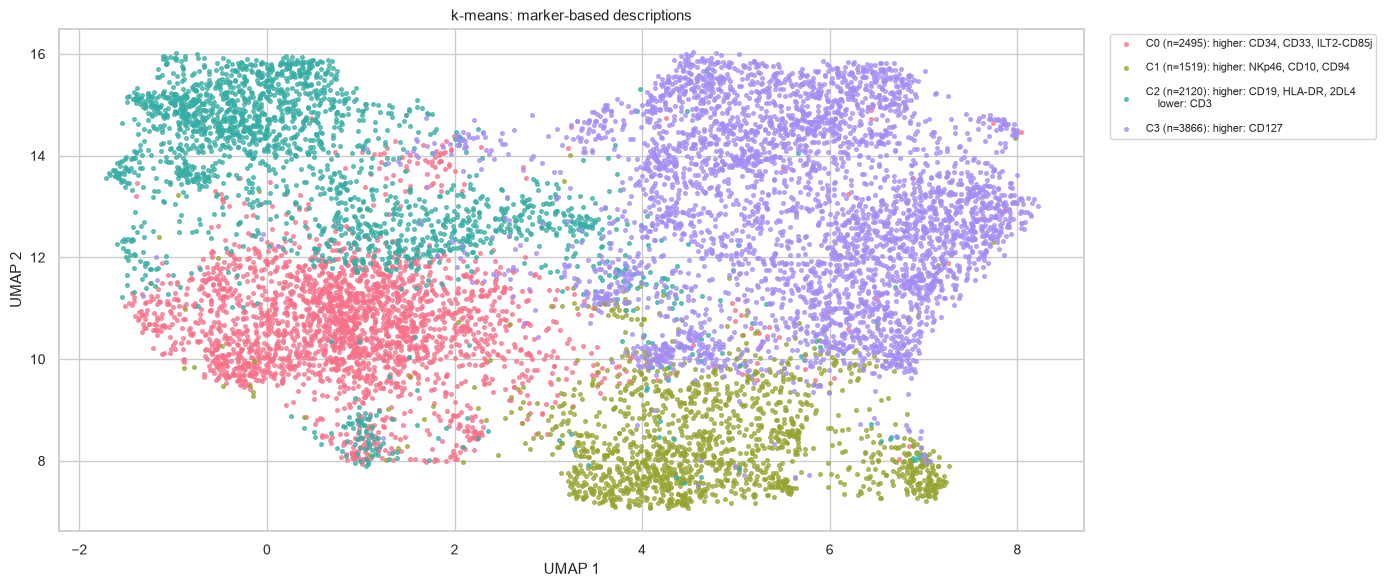

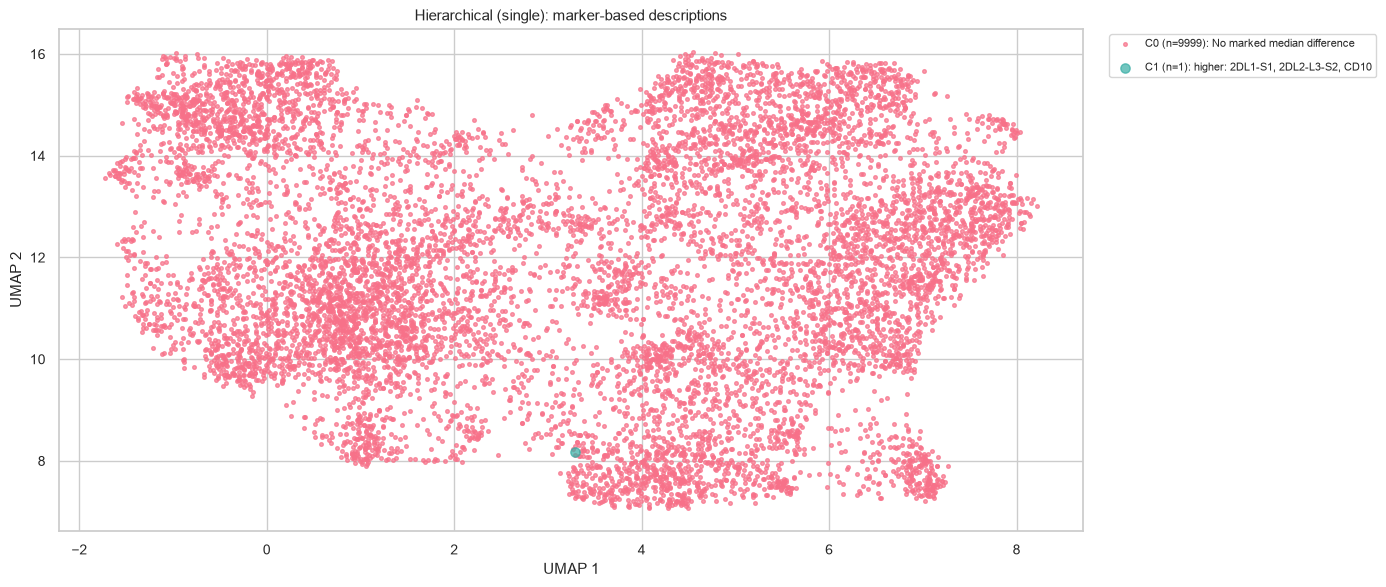

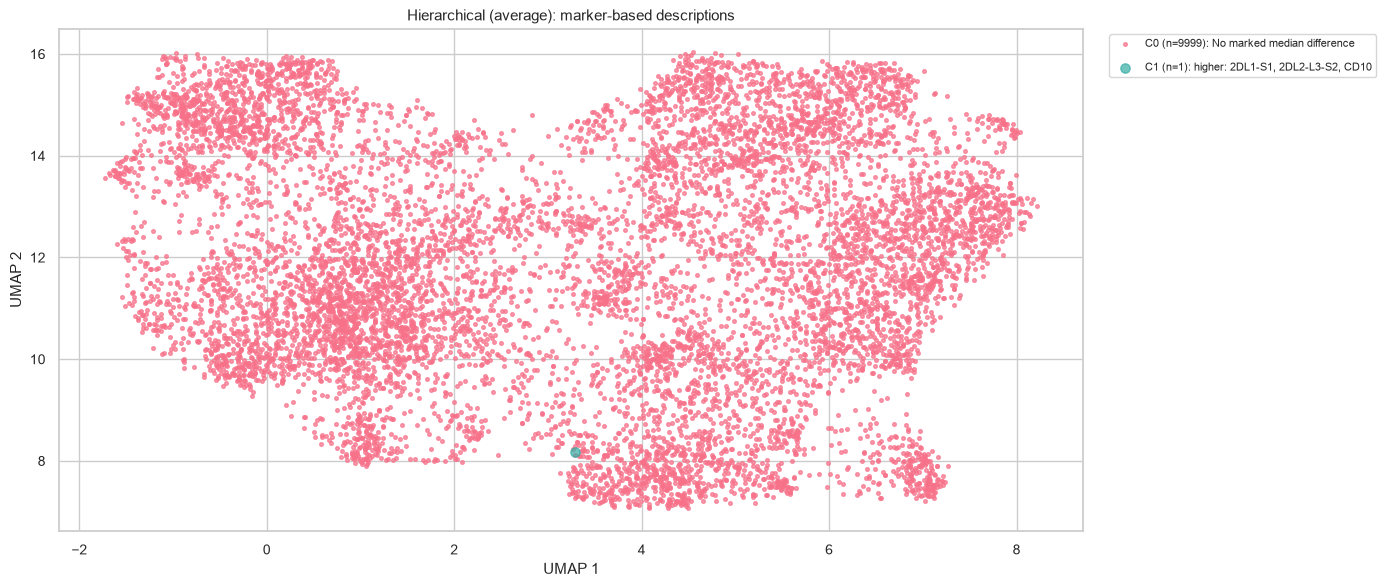

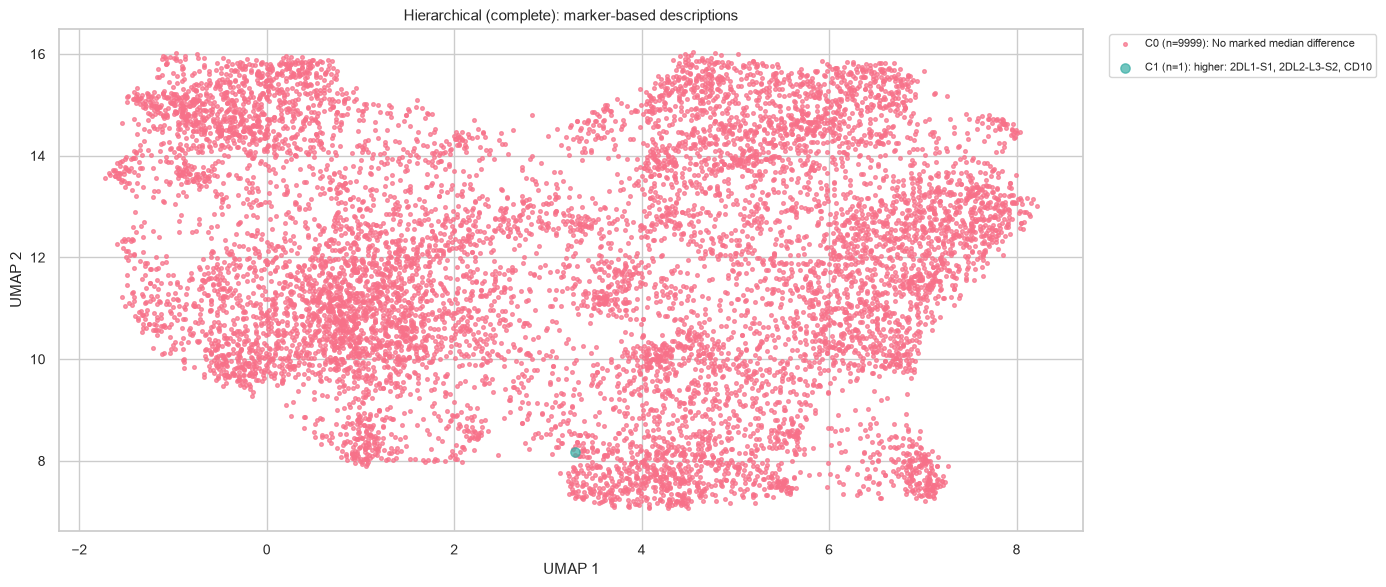

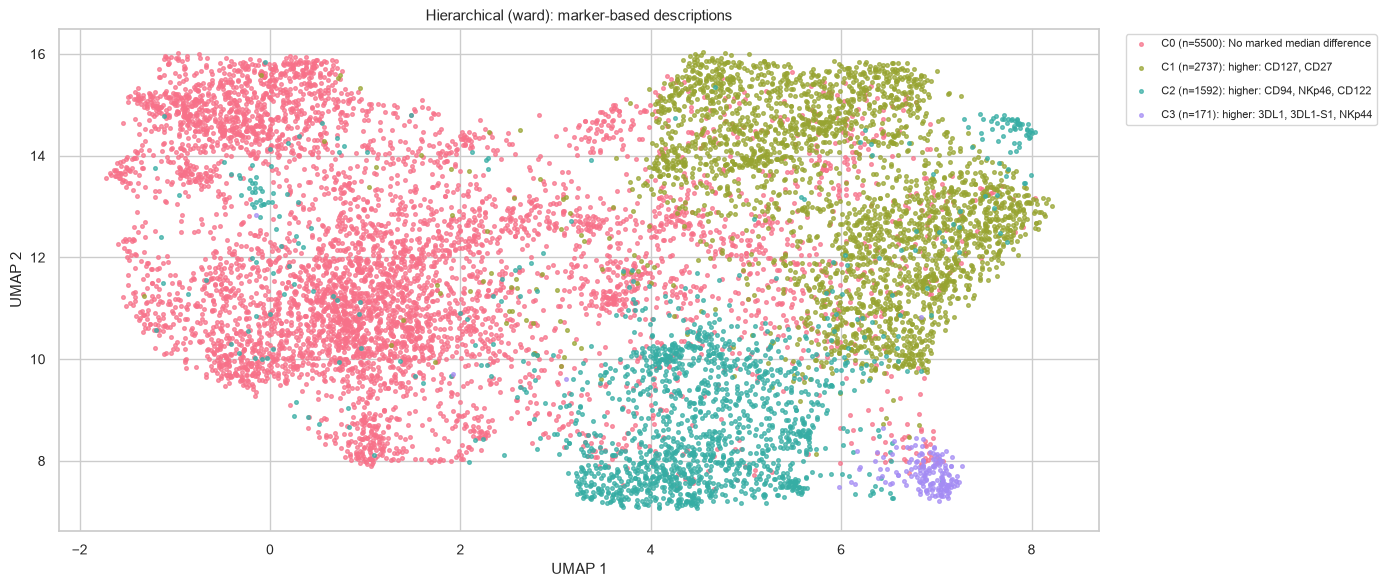

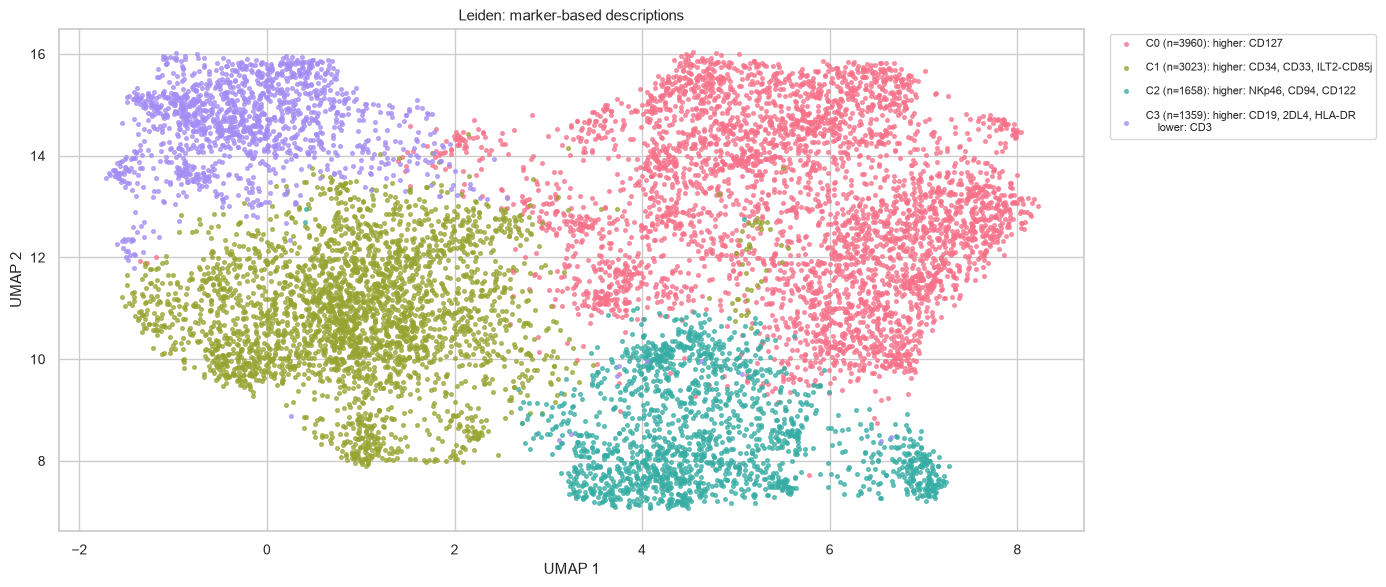

In [20]:
if winner_ids:
    plot_data = sc.AnnData(X)
    sc.pp.neighbors(plot_data, n_neighbors=30, use_rep="X", random_state=SEED)
    sc.tl.umap(plot_data, min_dist=0.3, random_state=SEED)
    embedding = plot_data.obsm["X_umap"]

    for name in ["k-means"] + [f"Hierarchical ({link})" for link in LINKAGES] + ["Leiden"]:
        if name not in winner_ids:
            continue
        labels = partitions[winner_ids[name]]
        fig, ax = plt.subplots(figsize=(14, 6))
        colors = sns.color_palette("husl", len(np.unique(labels)))
        for color, cluster in zip(colors, sorted(np.unique(labels))):
            selected = labels == cluster
            description = marker_annotations[name][cluster].replace("; ", "\n    ")
            ax.scatter(embedding[selected, 0], embedding[selected, 1],
                       s=45 if selected.sum() <= 2 else 7, alpha=0.7, color=color,
                       label=f"C{cluster} (n={selected.sum()}): {description}")
        ax.set(title=f"{name}: marker-based descriptions", xlabel="UMAP 1", ylabel="UMAP 2")
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, labelspacing=1.2)
        fig.tight_layout()
        plt.show()
else:
    print("No eligible configurations; no winner plots.")

References: [Jaccard stability in single-cell clustering](https://pmc.ncbi.nlm.nih.gov/articles/PMC8352506/), [sklearn metrics](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation), [SciPy linkage and Ward](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html), [Scanpy Leiden](https://scanpy.readthedocs.io/en/stable/api/generated/scanpy.tl.leiden.html).